In [1]:
import importlib
import os
import pandas as pd
import forecastcards
importlib.reload(forecastcards)

<module 'forecastcards' from 'C:\\Users\\hmod225\\Documents\\Code\\forecastcards\\forecastcards\\__init__.py'>

# Data Validation and Preparation

There are two main classes for forecast card data:  
 - **`Cardset`**: organization of forecastcards csv data 
 - **`Dataset`**: [pandas](https://pandas.pydata.org/) data created from a  validated `Cardset` that is cleaned for estimation

1. Find and validate data as a Cardset
2. Combine and format data for estimation



## 1 - Get and validate cards

Finds all the relevant cards and assigns them a type in order to compare to the data schema.

Returns a dictionary of card locations by card type.



data_loc = local_example_data_loc,
                 select_projects = [],
                 exclude_projects = [],
                 schemas = {},
                 schema_locs = github_master_schema_loc,


In [2]:
#example data repository
github_example_data = {'username':'e-lo','repository':'forecastcards','branch':'master'}

#instantiate a cardset with all the defaults
my_cards = forecastcards.Cardset(data_loc = github_example_data)

print("-- Card Locations by Type:",my_cards.card_locs_by_type)
print("-- Data schema Locations by Type:",my_cards.schema_locs)
print("-- Valid Projects",my_cards.validated_projects)

opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding lu123  - valid


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding rx123  - valid
-- Card Locations by Type: {'poi': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/poi.csv', 'https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/poi.csv'], 'scenario': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/scenarios.csv', 'https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/scenarios.csv'], 'observations': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/observations/observations-2015.csv', 'https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/observations/observations-1935.csv', 'https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/observations/observations-1960.csv'], 'fo

You can also get data from your a local repository by feeding in a local directory:

**NOTE** this will likely not work if you are running this in the cloud; or you will have to make modifications

In [3]:
file = r"C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\examples\ecdot-lu123-munchkin_tod\forecasts\forecast-A1-1960-1940-F1.csv"
df=pd.read_csv(file,dtype={'obs_value':float},usecols=["start_time", "end_time"])

In [4]:
df

,start_time,end_time
0,8:00:00,9:00:00
1,9:00:00,10:00:00
2,8:00:00,9:00:00
3,9:00:00,10:00:00
4,8:00:00,9:00:00
5,9:00:00,10:00:00
6,8:00:00,9:00:00
7,9:00:00,10:00:00


In [5]:
df['end_time']=df['end_time'].apply(lambda x: '23:59:59' if x in ['24:00:00','24:00'] else x)
df

,start_time,end_time
0,8:00:00,9:00:00
1,9:00:00,10:00:00
2,8:00:00,9:00:00
3,9:00:00,10:00:00
4,8:00:00,9:00:00
5,9:00:00,10:00:00
6,8:00:00,9:00:00
7,9:00:00,10:00:00


In [6]:
# this is assuming that you are running this file from a /notebooks directory which is at the same level as the /forecastcards module

local_example_data = r"C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\examples"

my_cards = forecastcards.Cardset(data_loc = local_example_data)

print(my_cards.validated_projects)


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding lu123  - valid
adding rx123  - valid
['lu123', 'rx123']


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


### Validating using a modified schema

If you modified the schema for any reason (i.e. you wanted to expand the project types), then you can validate the data compared to an alternate schema location, which is easy to set up using the **`Card_schema`** class.

It is good to use the class because it will also validate the schema for you.

In [7]:
#example data repository
github_example_data = {'username':'e-lo','repository':'forecastcards','branch':'master'}

#alternate schema repository location
my_new_schema_loc = {'username':'e-lo',
                     'repository':'forecastcards',
                     'branch':'master',
                     'subdir':'spec/en/'}

my_schemas = forecastcards.Card_schema(schema_dir = my_new_schema_loc)


#instantiate a cardset with all the defaults
my_cards = forecastcards.Cardset(data_loc = github_example_data, schema_locs = my_schemas.schema_locs)

Schema valid
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding lu123  - valid


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding rx123  - valid


## 2 - Combine and Format Data for Estimation

The **`Dataset`** class takes a cardset and turns it into a merged pandas dataframe.

If you don't tell it not to, it will complete all the merging and a default set of cleaning and variable coding on instantiation including:

 1. fix all missing values and clean records with required values . 
 2. code cateogrical variables as dummies  
 3. scale the estimation dataset by the forecast value . 


  - **`recode_na_vars`** - list of variables to recode NA to "missing"
  - **`no_na_vars`** - list of variables where having an NA isn't acceptable
  - **`categorical_cols_list`** - list of columns that will be recoded   
 - **`required_vars`** - list of variables that will be kept  
  - **`no_scale_cols`** - list of variables that won't be scaled
 

In [8]:
cardset = forecastcards.Cardset(data_loc = github_example_data)

dataset = forecastcards.Dataset(card_locs_by_type = cardset.card_locs_by_type, 
                                file_to_project_id = cardset.file_to_project_id
                               )
dataset.df

opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding lu123  - valid


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding rx123  - valid
Combining data
Fix Missing Values
Kept 16 of 16
Creating default categorical variables
Scaling dummy variables by forecast value


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\util.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  v_dist_df['start_hour'] = pd.to_datetime(v_dist_df['start_hour'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\util.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  v_dist_df['start_hour'] = pd.to_datetime(v_dist_df['start_hour'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\util.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  v_dist_df['start_hour'] = pd.to_datetime(v_dist_df['start_hour'])
C:\Users\hmod225\Documents\C

,project_size_small_project,project_size_large_project,creation_decade_1930,creation_decade_1940,creation_decade_2010,scenario_decade_1960,scenario_decade_2010,functional_class_Minor Arterial,forecast_system_type_pop-growth-rates,forecast_system_type_travel-model,...,project_type_land-use,agency_Emerald City DOT,forecaster_type_consultant,area_type_rural,facility_type_road,state_OZ,scenario_date,forecast_creation_date,forecast_value,obs_value
0,626.0,0.0,0.0,0.0,626.0,0.0,626.0,626.0,0.0,626.0,...,626.0,626.0,626.0,626.0,626.0,626.0,2015-01-01,2010-01-01,626.0,600.0
1,646.0,0.0,0.0,0.0,646.0,0.0,646.0,646.0,0.0,646.0,...,646.0,646.0,646.0,646.0,646.0,646.0,2015-01-01,2010-01-01,646.0,603.0
2,686.0,0.0,0.0,0.0,686.0,0.0,686.0,686.0,0.0,686.0,...,686.0,686.0,686.0,686.0,686.0,686.0,2015-01-01,2010-01-01,686.0,555.0
3,567.0,0.0,0.0,0.0,567.0,0.0,567.0,567.0,0.0,567.0,...,567.0,567.0,567.0,567.0,567.0,567.0,2015-01-01,2010-01-01,567.0,702.0
4,834.0,0.0,0.0,0.0,834.0,0.0,834.0,834.0,0.0,834.0,...,834.0,834.0,834.0,834.0,834.0,834.0,2015-01-01,2012-01-01,834.0,600.0
5,823.0,0.0,0.0,0.0,823.0,0.0,823.0,823.0,0.0,823.0,...,823.0,823.0,823.0,823.0,823.0,823.0,2015-01-01,2012-01-01,823.0,603.0
6,928.0,0.0,0.0,0.0,928.0,0.0,928.0,928.0,0.0,928.0,...,928.0,928.0,928.0,928.0,928.0,928.0,2015-01-01,2012-01-01,928.0,555.0
7,484.0,0.0,0.0,0.0,484.0,0.0,484.0,484.0,0.0,484.0,...,484.0,484.0,484.0,484.0,484.0,484.0,2015-01-01,2012-01-01,484.0,702.0
8,456.0,0.0,456.0,0.0,0.0,456.0,0.0,456.0,456.0,0.0,...,0.0,456.0,456.0,456.0,456.0,456.0,1960-09-01,1937-03-03,456.0,600.0
9,456.0,0.0,456.0,0.0,0.0,456.0,0.0,456.0,456.0,0.0,...,0.0,456.0,456.0,456.0,456.0,456.0,1960-09-01,1937-03-03,456.0,603.0


# Combine data from multiple sources

You can combine data from several github repositories as well as mix local and github data. This could be useful if you were using a shared, public data repository and you wanted to add your data in.

In [9]:
combined_gh_repo_cardset = forecastcards.Cardset(data_loc = github_example_data, exclude_projects=['lu123'])

combined_gh_repo_cardset.add_projects(data_loc=github_example_data, select_projects=['lu123'])

combined_gh_repo_cardset.validated_projects

opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
Excluding lu123  because it is in the exclusion list
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding rx123  - valid
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv
Excluding rx123  already in cardset


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding lu123  - valid


['rx123', 'lu123']

In [10]:
combined_gh_local_repo_cardset = forecastcards.Cardset(data_loc = github_example_data, exclude_projects=['lu123'])

combined_gh_local_repo_cardset.add_projects(data_loc=local_example_data, select_projects=['lu123'])

combined_gh_local_repo_cardset.card_locs_by_type


opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-lu123-munchkin_tod/project.csv
Excluding lu123  because it is in the exclusion list
opening https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/project.csv


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


adding rx123  - valid
adding lu123  - valid
Excluding rx123  already in cardset


C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'])
C:\Users\hmod225\Documents\Code\forecastcards\forecastcards\cardset.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time']   = pd.to_datetime(df['end_time'])


{'poi': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/poi.csv',
  'C:\\Users\\hmod225\\Documents\\Code\\forecastcards\\forecastcards\\examples\\ecdot-lu123-munchkin_tod\\poi.csv'],
 'scenario': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/scenarios.csv',
  'C:\\Users\\hmod225\\Documents\\Code\\forecastcards\\forecastcards\\examples\\ecdot-lu123-munchkin_tod\\scenarios.csv'],
 'observations': ['https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/observations/observations-1935.csv',
  'https://raw.githubusercontent.com/e-lo/forecastcards/master/forecastcards/examples/ecdot-rx123-ybr_hov/observations/observations-1960.csv',
  'C:\\Users\\hmod225\\Documents\\Code\\forecastcards\\forecastcards\\examples\\ecdot-lu123-munchkin_tod\\observations\\observations-2015.csv'],
 'forecast': ['https://raw.githubusercontent.com/e-lo/fo

# Explore Estimation Dataset


In [11]:
dataset.df.dtypes

project_size_small_project                      float64
project_size_large_project                      float64
creation_decade_1930                            float64
creation_decade_1940                            float64
creation_decade_2010                            float64
scenario_decade_1960                            float64
scenario_decade_2010                            float64
functional_class_Minor Arterial                 float64
forecast_system_type_pop-growth-rates           float64
forecast_system_type_travel-model               float64
project_type_hov                                float64
project_type_land-use                           float64
agency_Emerald City DOT                         float64
forecaster_type_consultant                      float64
area_type_rural                                 float64
facility_type_road                              float64
state_OZ                                        float64
scenario_date                            datetim

In [12]:
dataset.df.describe()
dataset.df

,project_size_small_project,project_size_large_project,creation_decade_1930,creation_decade_1940,creation_decade_2010,scenario_decade_1960,scenario_decade_2010,functional_class_Minor Arterial,forecast_system_type_pop-growth-rates,forecast_system_type_travel-model,...,project_type_land-use,agency_Emerald City DOT,forecaster_type_consultant,area_type_rural,facility_type_road,state_OZ,scenario_date,forecast_creation_date,forecast_value,obs_value
0,626.0,0.0,0.0,0.0,626.0,0.0,626.0,626.0,0.0,626.0,...,626.0,626.0,626.0,626.0,626.0,626.0,2015-01-01,2010-01-01,626.0,600.0
1,646.0,0.0,0.0,0.0,646.0,0.0,646.0,646.0,0.0,646.0,...,646.0,646.0,646.0,646.0,646.0,646.0,2015-01-01,2010-01-01,646.0,603.0
2,686.0,0.0,0.0,0.0,686.0,0.0,686.0,686.0,0.0,686.0,...,686.0,686.0,686.0,686.0,686.0,686.0,2015-01-01,2010-01-01,686.0,555.0
3,567.0,0.0,0.0,0.0,567.0,0.0,567.0,567.0,0.0,567.0,...,567.0,567.0,567.0,567.0,567.0,567.0,2015-01-01,2010-01-01,567.0,702.0
4,834.0,0.0,0.0,0.0,834.0,0.0,834.0,834.0,0.0,834.0,...,834.0,834.0,834.0,834.0,834.0,834.0,2015-01-01,2012-01-01,834.0,600.0
5,823.0,0.0,0.0,0.0,823.0,0.0,823.0,823.0,0.0,823.0,...,823.0,823.0,823.0,823.0,823.0,823.0,2015-01-01,2012-01-01,823.0,603.0
6,928.0,0.0,0.0,0.0,928.0,0.0,928.0,928.0,0.0,928.0,...,928.0,928.0,928.0,928.0,928.0,928.0,2015-01-01,2012-01-01,928.0,555.0
7,484.0,0.0,0.0,0.0,484.0,0.0,484.0,484.0,0.0,484.0,...,484.0,484.0,484.0,484.0,484.0,484.0,2015-01-01,2012-01-01,484.0,702.0
8,456.0,0.0,456.0,0.0,0.0,456.0,0.0,456.0,456.0,0.0,...,0.0,456.0,456.0,456.0,456.0,456.0,1960-09-01,1937-03-03,456.0,600.0
9,456.0,0.0,456.0,0.0,0.0,456.0,0.0,456.0,456.0,0.0,...,0.0,456.0,456.0,456.0,456.0,456.0,1960-09-01,1937-03-03,456.0,603.0


In [14]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.2 MB 12.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 12.1 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 11.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 11.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.1 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.1 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 11.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7

<Axes: xlabel='obs_value', ylabel='forecast_value'>

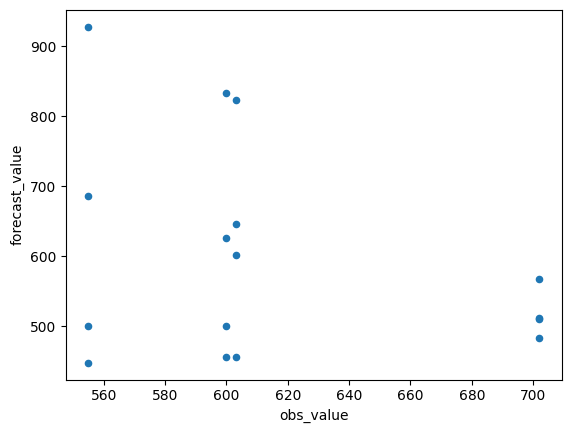

In [16]:
dataset.df.plot.scatter(y='forecast_value',
                         x='obs_value')
